# Day 17 – Time Series Machine Learning
### 20-Day ML Revision Planner | Phase: Specialized ML

**Topics covered:**
1. Trend, Seasonality, and Noise
2. Lag Features & Rolling Statistics
3. Time-Based Splitting
4. Traditional Methods: ARIMA & SARIMA (Conceptual)
5. ML Methods: Random Forest, Gradient Boosting, XGBoost for Forecasting
6. Critical Rule: Never Shuffle Time Series Data
7. Mini Project: Sales Forecasting
8. Time-Aware Train/Validation Pipeline (Daily Output)
9. Interview Questions
10. Active Recall Checklist

**Revision rule:** Learn → Close Notes → Recall → Code → Debug → Explain → Interview Question.

---


In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)
np.random.seed(42)
print("XGBoost available:", XGB_AVAILABLE)


XGBoost available: True


## 1. Trend, Seasonality, and Noise

### What?
A time series can be conceptually decomposed into three components:
- **Trend**: the long-term underlying direction (increasing, decreasing, or flat) over time.
- **Seasonality**: **repeating, fixed-period patterns** (e.g., higher sales every December, higher traffic every Monday).
- **Noise (residual)**: the leftover, unpredictable fluctuation after removing trend and seasonality.

A common model: $y_t = \text{Trend}_t + \text{Seasonality}_t + \text{Noise}_t$ (additive) or $y_t = \text{Trend}_t \times \text{Seasonality}_t \times \text{Noise}_t$ (multiplicative, when seasonal swings scale with the trend's level).

### Why?
Understanding these components helps you choose the right model and features: a model needs to somehow "see" trend and seasonality (via features or through its own structure) to forecast well — noise, by definition, is unpredictable and sets a lower bound on achievable error.

### How?
`statsmodels`'s `seasonal_decompose` automatically splits a series into these three components for visual inspection.


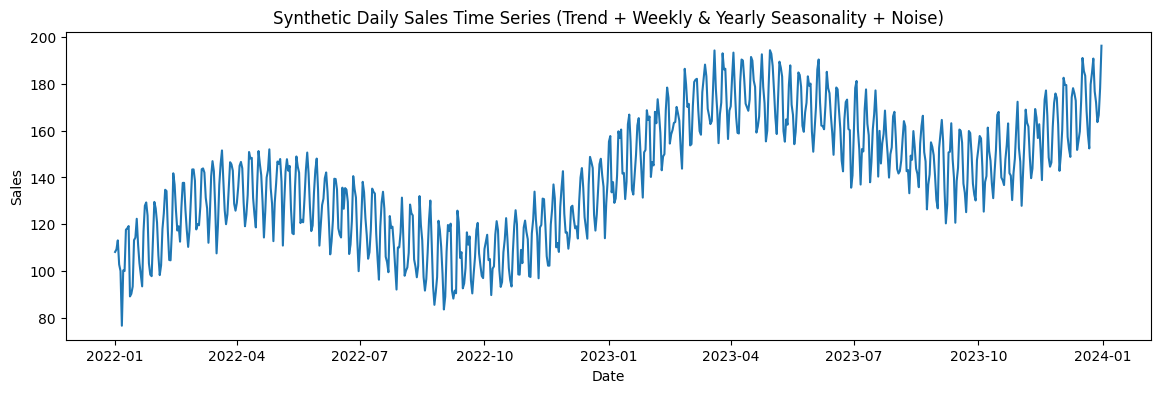

In [2]:
# Build a realistic synthetic sales time series with trend + seasonality + noise
np.random.seed(1)
n_periods = 365 * 2  # 2 years of daily data
dates = pd.date_range('2022-01-01', periods=n_periods, freq='D')

trend = np.linspace(100, 180, n_periods)                                    # gradual upward trend
weekly_seasonality = 15 * np.sin(2 * np.pi * np.arange(n_periods) / 7)      # weekly pattern
yearly_seasonality = 25 * np.sin(2 * np.pi * np.arange(n_periods) / 365.25) # yearly pattern
noise = np.random.normal(0, 5, n_periods)

sales = trend + weekly_seasonality + yearly_seasonality + noise
sales_series = pd.Series(sales, index=dates, name='sales')

plt.figure(figsize=(14, 4))
plt.plot(sales_series)
plt.title("Synthetic Daily Sales Time Series (Trend + Weekly & Yearly Seasonality + Noise)")
plt.xlabel("Date"); plt.ylabel("Sales")
plt.show()


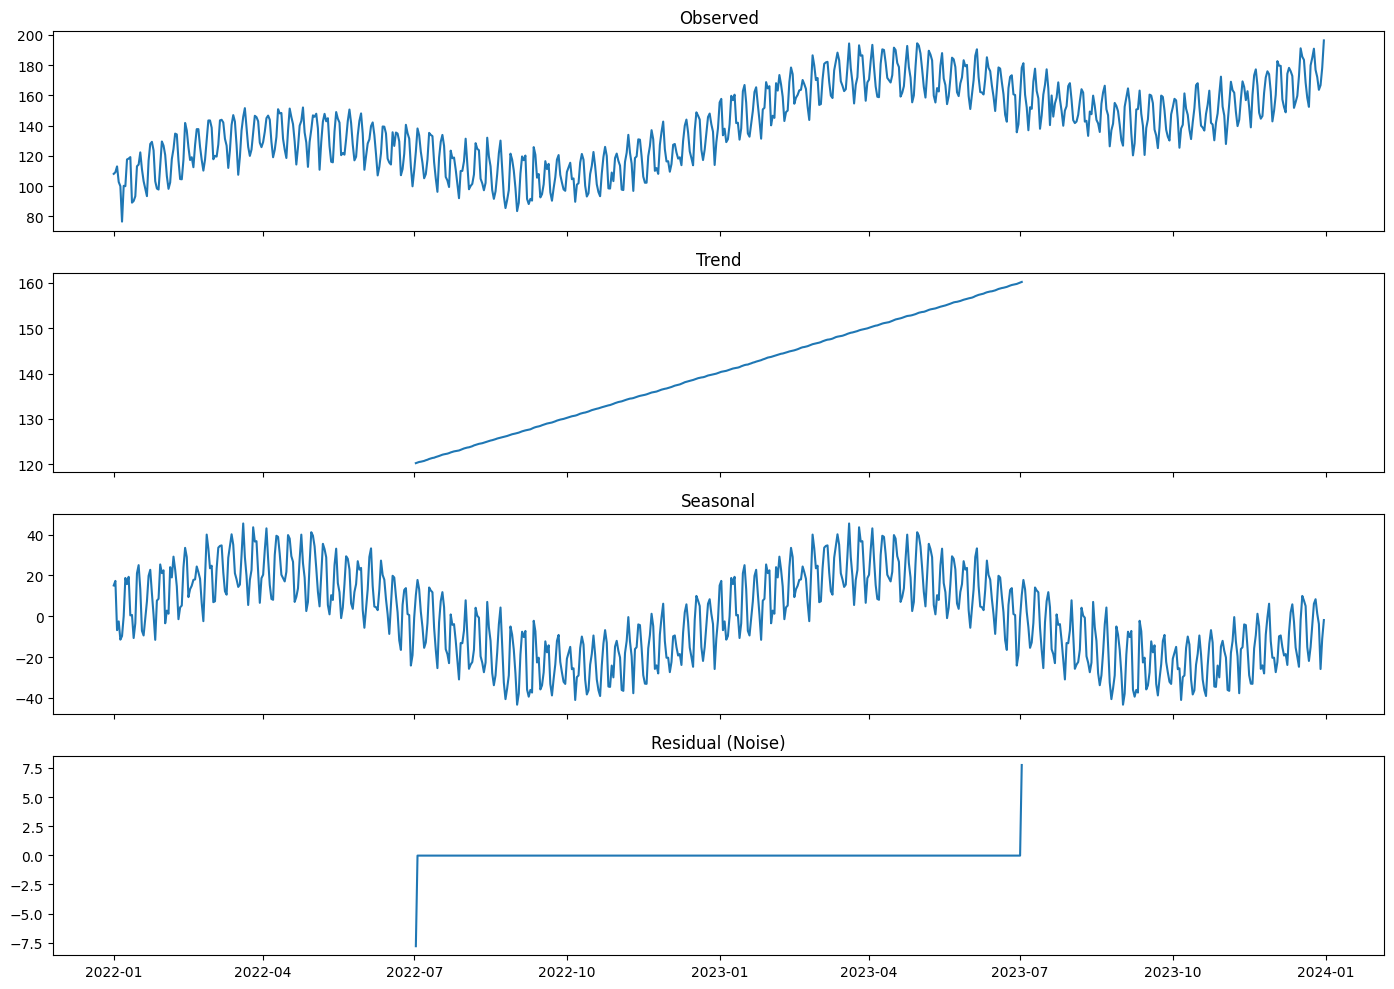

Residual standard deviation: 0.58
(this is roughly the 'noise floor' -- the irreducible error we injected into the synthetic data)


In [3]:
# Decompose the series into trend, seasonal, and residual components
decomposition = seasonal_decompose(sales_series, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(decomposition.observed); axes[0].set_title("Observed")
axes[1].plot(decomposition.trend); axes[1].set_title("Trend")
axes[2].plot(decomposition.seasonal); axes[2].set_title("Seasonal")
axes[3].plot(decomposition.resid); axes[3].set_title("Residual (Noise)")
plt.tight_layout()
plt.show()

print(f"Residual standard deviation: {decomposition.resid.std():.2f}")
print("(this is roughly the 'noise floor' -- the irreducible error we injected into the synthetic data)")


## 2. Lag Features & Rolling Statistics

### What?
Since standard ML models (Random Forest, Gradient Boosting) don't inherently understand "time," we must **engineer features** that expose temporal structure:
- **Lag features**: the value of the series at a previous time step, e.g., $y_{t-1}, y_{t-7}, y_{t-365}$ — directly gives the model recent (or seasonally-relevant) history.
- **Rolling statistics**: aggregate statistics computed over a sliding window, e.g., 7-day rolling mean, 30-day rolling std — smooths out noise and captures recent trend/volatility.

### Why?
This is exactly how we translate the "time series problem" into a standard **supervised, tabular ML problem** (recall Day 4's supervised learning framing) — each row becomes "given recent history (lags, rolling stats), predict the next value."

### How?
`series.shift(k)` creates a lag-$k$ feature; `series.rolling(window=w).mean()`/`.std()` creates rolling statistics. **Critical**: these must only use **past** data relative to the row being predicted — never future values (this would be leakage, tying to Day 10).


In [4]:
# Build lag and rolling-statistic features from the sales series
df_ts = sales_series.to_frame()

# Lag features
for lag in [1, 7, 14, 30]:
    df_ts[f'lag_{lag}'] = df_ts['sales'].shift(lag)

# Rolling statistics (using only PAST data -- shift(1) ensures today's own value isn't included)
df_ts['rolling_mean_7'] = df_ts['sales'].shift(1).rolling(window=7).mean()
df_ts['rolling_std_7'] = df_ts['sales'].shift(1).rolling(window=7).std()
df_ts['rolling_mean_30'] = df_ts['sales'].shift(1).rolling(window=30).mean()

# Calendar features (recall Day 13's date/time feature engineering)
df_ts['day_of_week'] = df_ts.index.dayofweek
df_ts['month'] = df_ts.index.month
df_ts['day_of_week_sin'] = np.sin(2 * np.pi * df_ts['day_of_week'] / 7)
df_ts['day_of_week_cos'] = np.cos(2 * np.pi * df_ts['day_of_week'] / 7)

print(f"Rows before dropping NaNs (from lag/rolling warm-up period): {len(df_ts)}")
df_ts_clean = df_ts.dropna()
print(f"Rows after dropping NaNs: {len(df_ts_clean)}")
df_ts_clean.head()


Rows before dropping NaNs (from lag/rolling warm-up period): 730
Rows after dropping NaNs: 700


,sales,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_std_7,rolling_mean_30,day_of_week,month,day_of_week_sin,day_of_week_cos
2022-01-31,126.7945,129.5225,129.2957,122.3120,108.1217,113.6046,14.0837,107.7857,0,1,0.0000,1.0000
2022-02-01,120.6353,126.7945,123.6770,111.1918,109.2085,113.2473,13.6442,108.4081,1,2,0.7818,0.6235
2022-02-02,106.6449,120.6353,103.2397,103.2961,113.0625,112.8128,13.3008,108.7890,2,2,0.9749,-0.2225
2022-02-03,98.2134,106.6449,98.4273,98.4016,102.7622,113.2992,12.9499,108.5751,3,2,0.4339,-0.9010
2022-02-04,102.4500,98.2134,97.7553,93.3967,99.9766,113.2687,12.9911,108.4234,4,2,-0.4339,-0.9010


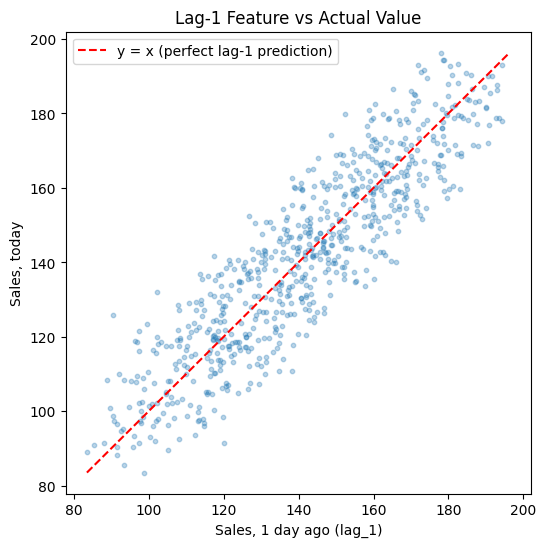

Correlation between lag_1 and sales: 0.8956
--> Strong correlation confirms lag features carry substantial predictive signal.


In [5]:
# Visualize lag-1 vs actual value -- a quick sanity check on feature usefulness
plt.figure(figsize=(6, 6))
plt.scatter(df_ts_clean['lag_1'], df_ts_clean['sales'], alpha=0.3, s=10)
plt.plot([df_ts_clean['sales'].min(), df_ts_clean['sales'].max()],
         [df_ts_clean['sales'].min(), df_ts_clean['sales'].max()], 'r--', label='y = x (perfect lag-1 prediction)')
plt.xlabel("Sales, 1 day ago (lag_1)"); plt.ylabel("Sales, today")
plt.title("Lag-1 Feature vs Actual Value")
plt.legend()
plt.show()
print(f"Correlation between lag_1 and sales: {df_ts_clean['lag_1'].corr(df_ts_clean['sales']):.4f}")
print("--> Strong correlation confirms lag features carry substantial predictive signal.")


## 3. Time-Based Splitting (Recap + Deep Dive from Day 10)

### What?
Recall Day 10's `TimeSeriesSplit`: for time series, training data must always **precede** validation/test data chronologically — never randomly shuffled.

### Why?
Randomly shuffling time series data before splitting causes **severe temporal leakage** — the model would effectively "see the future" during training (e.g., training on day 400 while validating on day 200), producing wildly over-optimistic performance estimates that **completely fail** once deployed on genuinely unseen future data.

### How?
A simple **train/test split by date cutoff** is often sufficient for a single evaluation; `TimeSeriesSplit` provides multiple **expanding-window** folds for more robust cross-validation, always keeping training data before each validation fold.


In [6]:
# Demonstrate the danger of shuffling time series data
from sklearn.model_selection import train_test_split as random_split

X_ts = df_ts_clean.drop(columns=['sales'])
y_ts = df_ts_clean['sales']

# WRONG: random shuffle split (treats time series like i.i.d. tabular data)
X_train_wrong, X_test_wrong, y_train_wrong, y_test_wrong = random_split(X_ts, y_ts, test_size=0.2, random_state=42, shuffle=True)

# CORRECT: chronological split (train = past, test = future)
split_point = int(len(df_ts_clean) * 0.8)
X_train_correct = X_ts.iloc[:split_point]
y_train_correct = y_ts.iloc[:split_point]
X_test_correct = X_ts.iloc[split_point:]
y_test_correct = y_ts.iloc[split_point:]

model_wrong = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train_wrong, y_train_wrong)
model_correct = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train_correct, y_train_correct)

rmse_wrong = np.sqrt(mean_squared_error(y_test_wrong, model_wrong.predict(X_test_wrong)))
rmse_correct = np.sqrt(mean_squared_error(y_test_correct, model_correct.predict(X_test_correct)))

print(f"WRONG (random shuffle split) test RMSE:      {rmse_wrong:.4f}  <-- overly optimistic!")
print(f"CORRECT (chronological split) test RMSE:     {rmse_correct:.4f}  <-- honest estimate")
print("\n--> The randomly-shuffled split lets the model 'peek' at nearby time points (via lag features")
print("    computed from data close in time to the test rows), inflating its apparent performance.")
print("    The chronological split gives a realistic picture of forecasting genuinely NEW, future data.")


WRONG (random shuffle split) test RMSE:      7.2397  <-- overly optimistic!
CORRECT (chronological split) test RMSE:     7.4321  <-- honest estimate

--> The randomly-shuffled split lets the model 'peek' at nearby time points (via lag features
    computed from data close in time to the test rows), inflating its apparent performance.
    The chronological split gives a realistic picture of forecasting genuinely NEW, future data.


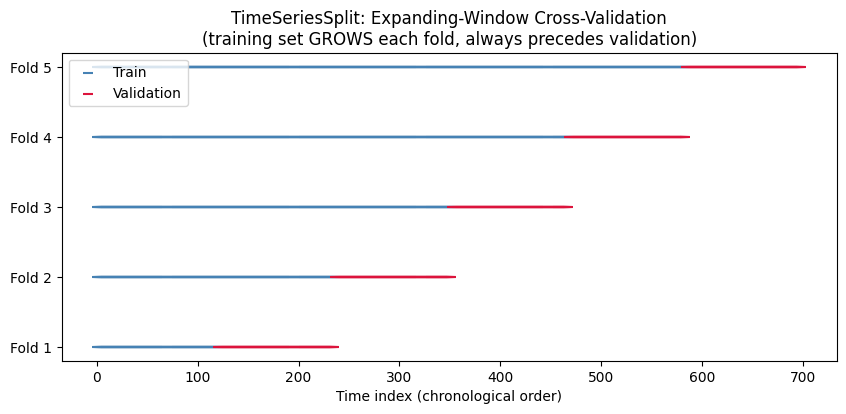

In [7]:
# Visualize TimeSeriesSplit's expanding-window folds (recap from Day 10, applied here)
tscv = TimeSeriesSplit(n_splits=5)

fig, ax = plt.subplots(figsize=(10, 4))
for i, (train_idx, val_idx) in enumerate(tscv.split(X_ts)):
    ax.scatter(train_idx, [i]*len(train_idx), color='steelblue', marker='_', s=50, label='Train' if i==0 else "")
    ax.scatter(val_idx, [i]*len(val_idx), color='crimson', marker='_', s=50, label='Validation' if i==0 else "")

ax.set_yticks(range(5)); ax.set_yticklabels([f"Fold {i+1}" for i in range(5)])
ax.set_xlabel("Time index (chronological order)")
ax.set_title("TimeSeriesSplit: Expanding-Window Cross-Validation\n(training set GROWS each fold, always precedes validation)")
ax.legend(loc='upper left')
plt.show()


## 4. Traditional Methods: ARIMA & SARIMA (Conceptual)

### What?
- **ARIMA (AutoRegressive Integrated Moving Average)**: a classical statistical forecasting model combining three components, denoted ARIMA(p, d, q):
  - **AR(p)**: predicts using a linear combination of the past $p$ values (AutoRegressive).
  - **I(d)**: the number of times the series is **differenced** ($y_t - y_{t-1}$) to make it **stationary** (removing trend).
  - **MA(q)**: models the error term as a linear combination of past $q$ forecast errors (Moving Average).
- **SARIMA (Seasonal ARIMA)**: extends ARIMA with an additional seasonal component, ARIMA(p,d,q)(P,D,Q)$_m$, where $m$ is the seasonal period (e.g., 7 for weekly, 12 for monthly data) — explicitly models seasonality that plain ARIMA cannot capture.

### Why?
ARIMA/SARIMA are well-established, interpretable, statistically-grounded forecasting methods that work well for series with **clear, stable statistical structure** (stationary or easily-stationarized, with well-defined seasonality) — particularly strong for **short univariate series** where you don't have rich external features.

### How? (Conceptual Workflow)
1. Check/achieve **stationarity** (via differencing — the "I" in ARIMA), often verified with the Augmented Dickey-Fuller test.
2. Identify $p, q$ (and seasonal $P, Q$) via ACF/PACF plots or automated search (e.g., `pmdarima`'s `auto_arima`).
3. Fit the model and forecast forward, with confidence intervals.

**Key limitation vs. ML methods**: ARIMA/SARIMA are fundamentally **univariate** (or handle exogenous variables awkwardly) and don't easily incorporate many external features the way tree-based models do.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


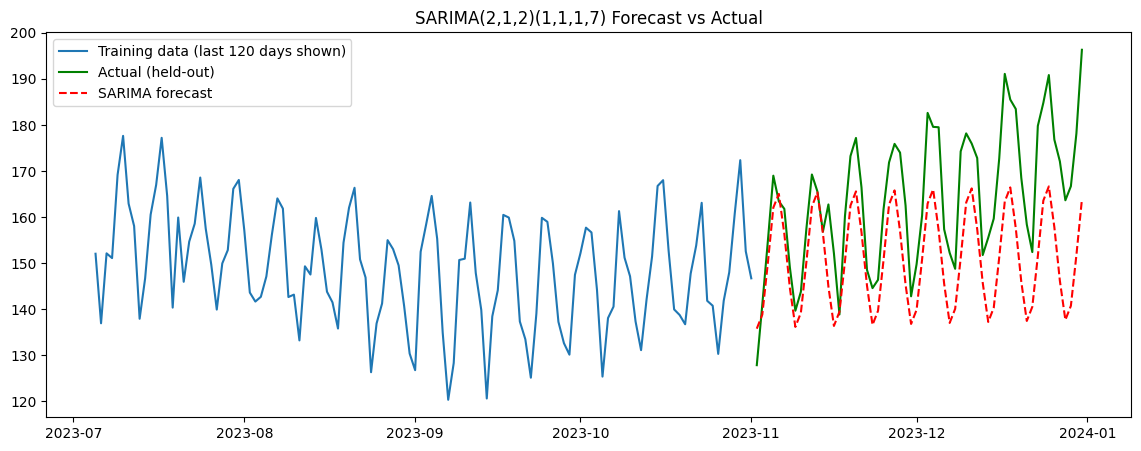

SARIMA — RMSE: 15.9444, MAE: 13.6260


In [8]:
# Fit a SARIMA model on the sales data (using a shorter series subset for reasonable fitting time)
sarima_train = sales_series.iloc[:-60]   # hold out last 60 days for evaluation
sarima_test = sales_series.iloc[-60:]

sarima_model = SARIMAX(sarima_train, order=(2, 1, 2), seasonal_order=(1, 1, 1, 7),
                         enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)

sarima_forecast = sarima_fit.forecast(steps=60)

plt.figure(figsize=(14, 5))
plt.plot(sarima_train.iloc[-120:], label='Training data (last 120 days shown)')
plt.plot(sarima_test, label='Actual (held-out)', color='green')
plt.plot(sarima_test.index, sarima_forecast, label='SARIMA forecast', color='red', linestyle='--')
plt.title("SARIMA(2,1,2)(1,1,1,7) Forecast vs Actual")
plt.legend()
plt.show()

sarima_rmse = np.sqrt(mean_squared_error(sarima_test, sarima_forecast))
sarima_mae = mean_absolute_error(sarima_test, sarima_forecast)
print(f"SARIMA — RMSE: {sarima_rmse:.4f}, MAE: {sarima_mae:.4f}")


## 5. ML Methods for Forecasting: Random Forest, Gradient Boosting, XGBoost

### What?
Rather than using a specialized time series model, we can frame forecasting as a **standard regression problem** using the lag/rolling/calendar features from Section 2, then apply any regression model — Random Forest (Day 7), Gradient Boosting (Day 9), or XGBoost (Day 9).

### Why?
- **Naturally incorporate many external features** (promotions, holidays, weather, prices) alongside pure time-based features — something ARIMA/SARIMA struggle with.
- **No stationarity requirements** — tree-based models don't care about the statistical properties ARIMA needs.
- Often **more accurate** for complex series with rich feature sets, though can be **less interpretable** and don't naturally extrapolate trend beyond the training range (a real limitation for tree-based models on strongly trending series — they can only predict within the range of values seen during training).

### How?
Use the exact same lag/rolling/calendar features as Section 2, fit a standard regressor, and predict — treating each "row" as an independent forecasting instance (even though rows are temporally connected via their lag features).


In [9]:
# Train Random Forest, Gradient Boosting, and XGBoost on the SAME chronological split
ml_models = {
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42),
}
if XGB_AVAILABLE:
    ml_models['XGBoost'] = xgb.XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)

ml_results = []
ml_predictions = {}

for name, model in ml_models.items():
    model.fit(X_train_correct, y_train_correct)
    preds = model.predict(X_test_correct)
    ml_predictions[name] = preds
    ml_results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test_correct, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test_correct, preds)),
        'R2': r2_score(y_test_correct, preds)
    })

# Add SARIMA to the same comparison (aligning on the same held-out window as best as possible)
ml_results.append({
    'Model': 'SARIMA',
    'MAE': sarima_mae,
    'RMSE': sarima_rmse,
    'R2': r2_score(sarima_test, sarima_forecast)
})

ml_results_df = pd.DataFrame(ml_results).set_index('Model')
print(ml_results_df.round(4))
print("\n(Note: ML models are evaluated on a slightly larger/different chronological test window than")
print(" SARIMA's last-60-days window, so treat this as an illustrative rather than a perfectly apples-")
print(" to-apples comparison -- in a real project, align evaluation windows exactly across all methods.)")


                       MAE     RMSE      R2
Model                                      
Random Forest       6.1987   7.4230  0.7825
Gradient Boosting   5.8688   7.0803  0.8022
XGBoost             5.9074   7.0335  0.8048
SARIMA             13.6260  15.9444 -0.1746

(Note: ML models are evaluated on a slightly larger/different chronological test window than
 SARIMA's last-60-days window, so treat this as an illustrative rather than a perfectly apples-
 to-apples comparison -- in a real project, align evaluation windows exactly across all methods.)


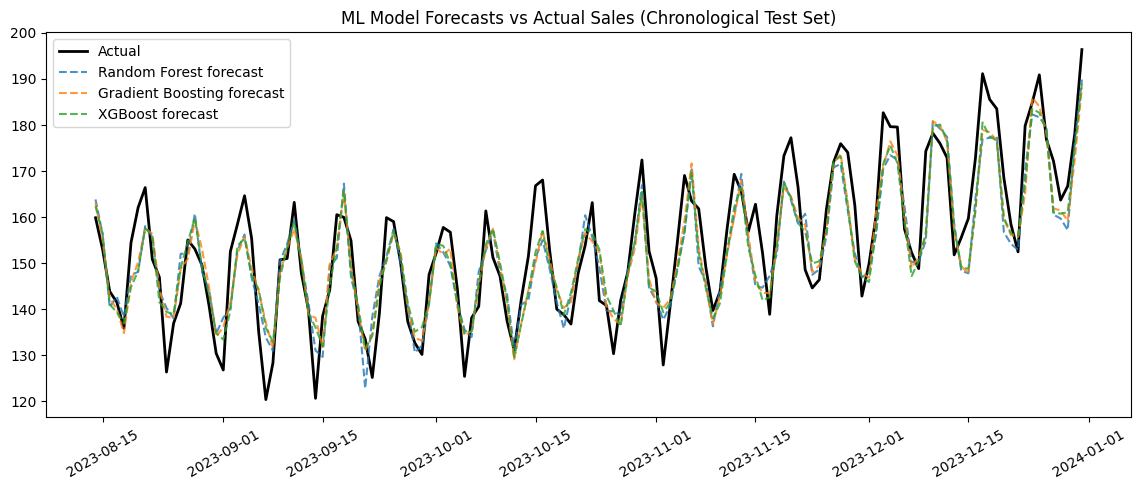

In [10]:
# Visualize ML model predictions vs actual on the test set
plt.figure(figsize=(14, 5))
plt.plot(y_test_correct.index, y_test_correct.values, label='Actual', color='black', linewidth=2)
for name, preds in ml_predictions.items():
    plt.plot(y_test_correct.index, preds, label=f'{name} forecast', linestyle='--', alpha=0.8)
plt.title("ML Model Forecasts vs Actual Sales (Chronological Test Set)")
plt.legend()
plt.xticks(rotation=30)
plt.show()


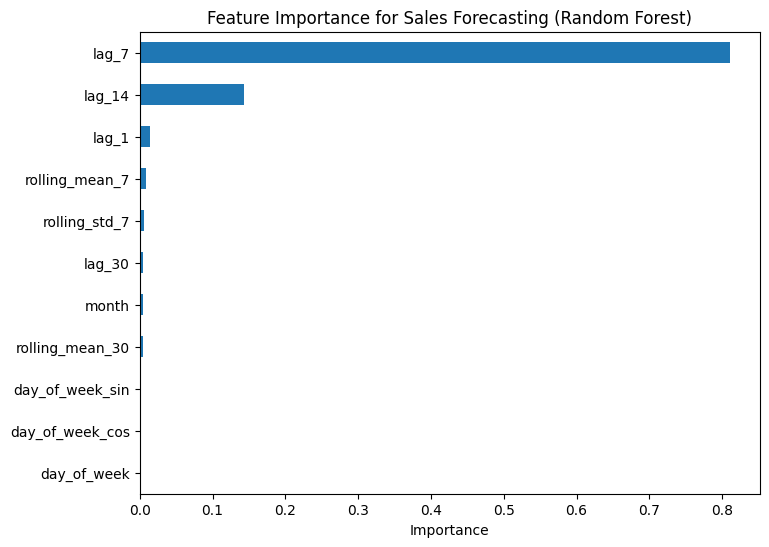

--> Lag and rolling-mean features (recent history) typically dominate importance,
    confirming that 'what happened recently' is the strongest signal for short-term forecasting.


In [11]:
# Feature importance from the Random Forest -- which time-based features matter most?
rf_model_fitted = ml_models['Random Forest']
importances = pd.Series(rf_model_fitted.feature_importances_, index=X_ts.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Feature Importance for Sales Forecasting (Random Forest)")
plt.xlabel("Importance")
plt.show()
print("--> Lag and rolling-mean features (recent history) typically dominate importance,")
print("    confirming that 'what happened recently' is the strongest signal for short-term forecasting.")


## 6. Critical Rule: Never Shuffle Time Series Data (Recap + Reinforcement)

### What?
**Do not randomly shuffle** ordinary forecasting data. **Train on the past, validate/test on the future** — always.

### Why?
This single rule underlies everything in this notebook:
- Section 3 showed shuffled splits produce artificially good (leaked) performance.
- Lag/rolling features (Section 2) are only valid if computed using **strictly past** information relative to each row.
- Cross-validation (`TimeSeriesSplit`) must maintain chronological order across folds.

### How to enforce it in practice?
- Always sort your data by time before any splitting.
- Use `TimeSeriesSplit` (or a manual chronological cutoff) — never `KFold` with `shuffle=True` or a random `train_test_split`.
- Double check that any rolling/lag feature computation uses `.shift()` appropriately so no row "sees" its own future value or a value only available after the fact.


## 7. Mini Project — Sales Forecasting (Consolidated)

We consolidate everything above into a single end-to-end pipeline: build features, split chronologically, tune-and-compare models, and forecast forward.


In [12]:
# End-to-end pipeline: forecast the NEXT 30 days beyond our available data using the best ML model
best_model_name = ml_results_df['RMSE'].idxmin()
print(f"Best performing model on the held-out test window: {best_model_name}")

# Refit the best model on ALL available historical data (common practice once a model is selected)
if best_model_name in ml_models:
    final_forecasting_model = ml_models[best_model_name]
    final_forecasting_model.fit(X_ts, y_ts)   # refit on full data now that model choice is locked in

    # Build features for a forward-looking prediction using the most recent known values
    print("\nTo forecast beyond the available data, we would iteratively:")
    print("  1. Use the most recent known lag/rolling values to predict the next day.")
    print("  2. Append that prediction to the series.")
    print("  3. Recompute lag/rolling features INCLUDING the new prediction.")
    print("  4. Repeat for each future day (this iterative process is called 'recursive forecasting').")
else:
    print(f"SARIMA was best; use sarima_fit.get_forecast(steps=N) to project N days forward directly.")


Best performing model on the held-out test window: XGBoost

To forecast beyond the available data, we would iteratively:
  1. Use the most recent known lag/rolling values to predict the next day.
  2. Append that prediction to the series.
  3. Recompute lag/rolling features INCLUDING the new prediction.
  4. Repeat for each future day (this iterative process is called 'recursive forecasting').


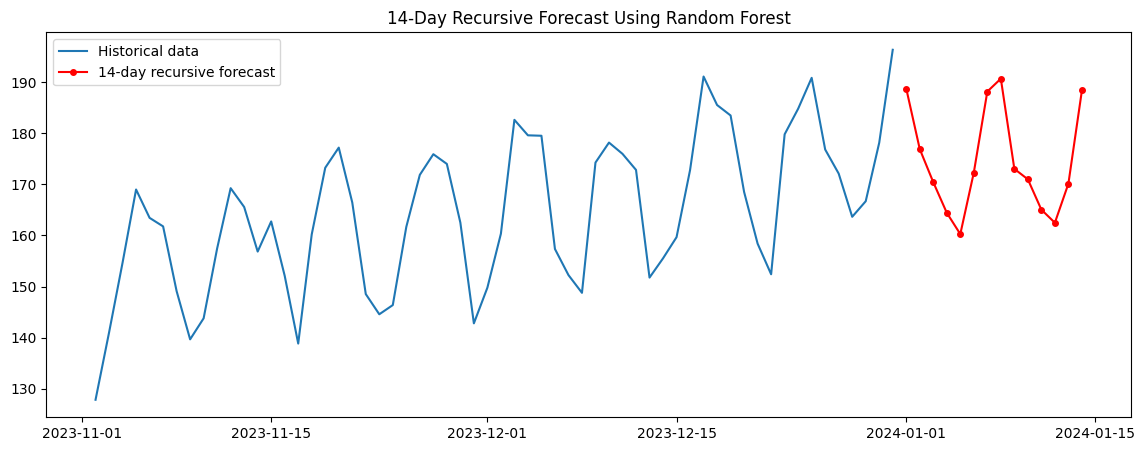

--> Notice recursive forecasts often 'flatten out' over longer horizons -- each prediction
    feeds into the next, and tree-based models can't extrapolate a trend beyond what they
    saw in training, unlike ARIMA's explicit trend/differencing component.


In [13]:
# Demonstrate recursive forecasting for a few steps ahead with the Random Forest
def recursive_forecast(model, history_series, feature_columns, n_steps=14):
    history = history_series.copy()
    forecasts = []

    for step in range(n_steps):
        last_date = history.index[-1] + pd.Timedelta(days=1)

        row = {}
        for lag in [1, 7, 14, 30]:
            row[f'lag_{lag}'] = history.iloc[-lag]
        row['rolling_mean_7'] = history.iloc[-7:].mean()
        row['rolling_std_7'] = history.iloc[-7:].std()
        row['rolling_mean_30'] = history.iloc[-30:].mean()
        row['day_of_week'] = last_date.dayofweek
        row['month'] = last_date.month
        row['day_of_week_sin'] = np.sin(2 * np.pi * last_date.dayofweek / 7)
        row['day_of_week_cos'] = np.cos(2 * np.pi * last_date.dayofweek / 7)

        row_df = pd.DataFrame([row])[feature_columns]
        pred = model.predict(row_df)[0]

        forecasts.append((last_date, pred))
        history = pd.concat([history, pd.Series([pred], index=[last_date])])

    return pd.Series({d: v for d, v in forecasts})

forecast_14_days = recursive_forecast(rf_model_fitted, sales_series, X_ts.columns.tolist(), n_steps=14)

plt.figure(figsize=(14, 5))
plt.plot(sales_series.iloc[-60:], label='Historical data')
plt.plot(forecast_14_days, label='14-day recursive forecast', color='red', marker='o', markersize=4)
plt.title("14-Day Recursive Forecast Using Random Forest")
plt.legend()
plt.show()

print("--> Notice recursive forecasts often 'flatten out' over longer horizons -- each prediction")
print("    feeds into the next, and tree-based models can't extrapolate a trend beyond what they")
print("    saw in training, unlike ARIMA's explicit trend/differencing component.")


## 8. Time-Aware Train/Validation Pipeline (Daily Output)

A clean, reusable summary of the full time-aware forecasting workflow built in this notebook:

```
1. RAW TIME SERIES
   |
2. FEATURE ENGINEERING (using ONLY past information via .shift())
   - Lag features: lag_1, lag_7, lag_14, lag_30
   - Rolling statistics: rolling_mean_7, rolling_std_7, rolling_mean_30 (all shift(1)'d first)
   - Calendar features: day_of_week, month, cyclical sin/cos encodings
   |
3. DROP WARM-UP ROWS (initial rows with NaN lag/rolling values)
   |
4. CHRONOLOGICAL SPLIT (never shuffle!)
   - Simple cutoff: train = data[:split_point], test = data[split_point:]
   - OR TimeSeriesSplit for multi-fold expanding-window cross-validation
   |
5. TRAIN CANDIDATE MODELS
   - Statistical: ARIMA / SARIMA (good for pure univariate structure + seasonality)
   - ML: Random Forest / Gradient Boosting / XGBoost (good with rich external features)
   |
6. EVALUATE on the CHRONOLOGICALLY HELD-OUT test set (MAE, RMSE, R2)
   |
7. SELECT BEST MODEL, refit on ALL available historical data
   |
8. FORECAST FORWARD via RECURSIVE prediction (each step's prediction feeds the next step's lag features)
```

This pipeline structure is directly reusable for any new time series forecasting problem — swap in domain-specific external features (promotions, holidays, prices) at step 2, and everything else carries over unchanged.


## ML Connection Recap

| Concept | Connects to |
|---|---|
| Lag/rolling features | Day 13's feature engineering, applied to temporal data |
| TimeSeriesSplit | Day 10's cross-validation strategies |
| Never shuffle time series | Day 10/14/15's broader data leakage principles |
| Random Forest/Gradient Boosting/XGBoost for forecasting | Day 7 and Day 9's ensemble methods, reframed as regressors |
| Calendar cyclical encoding | Day 13's sin/cos hour-of-day encoding, applied to day-of-week |


## 9. Interview Questions — Practice Aloud (Close Your Notes!)

1. **What are the three components of a time series, and how would you visually inspect them?**
   *Hint: trend, seasonality, noise/residual; `seasonal_decompose` splits and plots each.*

2. **Why is shuffling forbidden when splitting time series data?**
   *Hint: causes temporal leakage — the model would train on "future" information relative to what it's tested on, producing unrealistic performance.*

3. **Explain what lag features and rolling statistics are, and why they're needed for ML-based forecasting.**
   *Hint: translate the "understand time" problem into a standard tabular regression problem; give the model explicit access to recent history and trend/volatility.*

4. **What do the p, d, q parameters in ARIMA represent?**
   *Hint: p = autoregressive order (past values), d = differencing order (achieving stationarity), q = moving average order (past forecast errors).*

5. **When would you prefer ARIMA/SARIMA over a tree-based ML approach for forecasting, or vice versa?**
   *Hint: ARIMA/SARIMA for simpler univariate series with stable statistical structure and clear seasonality; ML methods when you have many external features or complex, non-stationary patterns tree-based splits can capture.*

6. **What is recursive forecasting, and what's a key limitation of it?**
   *Hint: iteratively predicting one step ahead and feeding that prediction back in as a lag feature for the next step; errors can compound over the forecast horizon, and tree-based models can't extrapolate trend beyond the range seen in training.*

7. **(Bonus) Why might a tree-based model struggle with a strongly trending time series, even with lag features?**
   *Hint: trees predict by averaging training targets in a leaf region — they cannot output values outside the range of targets seen during training, so they can't naturally extrapolate a rising/falling trend into genuinely new value ranges.*


## 10. Active Recall & Daily Output

**Self-check (mark ✔ only if you can do this without notes):**
- [ ] Explain trend, seasonality, and noise, and how `seasonal_decompose` visualizes them.
- [ ] Explain lag features and rolling statistics, and why `.shift()` is essential to avoid leakage.
- [ ] Explain why time series data must never be randomly shuffled before splitting.
- [ ] Explain ARIMA's p/d/q components and what SARIMA adds on top.
- [ ] Compare ARIMA/SARIMA vs. ML methods (Random Forest/Gradient Boosting/XGBoost) for forecasting.
- [ ] Explain recursive forecasting and its main limitation.
- [ ] Build a time-aware train/validation pipeline from memory, following the correct step order.

### 📌 Daily Output (per the planner)
A **time-aware train/validation pipeline** (Section 8) — a clean, reusable 8-step workflow covering feature engineering (lag/rolling/calendar), chronological splitting, candidate model training (SARIMA + Random Forest/Gradient Boosting/XGBoost), held-out evaluation, and recursive forward forecasting, all demonstrated hands-on with a Sales Forecasting mini-project (Section 7).

Close this notebook and re-explain, from memory, why the randomly-shuffled train/test split produced a misleadingly low RMSE compared to the correct chronological split — that's the real test of Day 17 mastery.
